# Parameter Estimation: Approximate Bayesian Computation

Here we demonstrate how PyGOM uses Approximate Bayesian Computation (ABC) to estimate posterior distributions for parameters given a candidate model and some data.
As an example, we use synthetic data produced by PyGOM's {doc}`solve_stochast <../model_solver>` function, the result of a stochastic epidemic simulation of an SEIR model with parameters:

$\beta=0.35,\quad \alpha=0.5,\quad \gamma=0.25,\quad n_{\text{pop}}=10^4,\quad I(t=0)=5$

Loading in the data file:

In [1]:
import numpy as np

out = np.loadtxt('seir_epi_data.txt')
t = out[:, 0]
sol_i_r = out[:, 1:3]

We inspect the time series of the daily infected and removed populations:

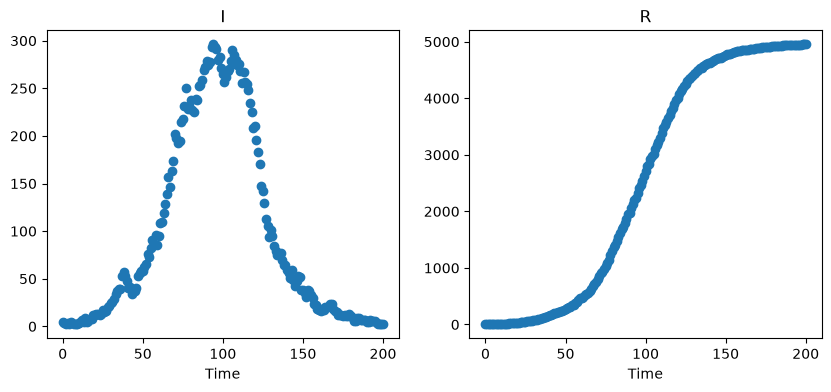

In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10,4))

states = ["I", "R"]

for i in range(2):
    axes[i].scatter(t, sol_i_r[:, i])
    axes[i].set_title(states[i])
    axes[i].set_xlabel('Time')

```{note}
We typically do not have access to information regarding the total infected population. More commonly reported is the number of new cases in a given time period (or infection times).
Furthermore, we are unlikely to know the removed population, unless, for example, the disease results in death with high probability.
Nevertheless, the purpose of this chapter is to demonstrate model fitting given a data set and so these departures from reality do not undermine the key messages.
```

In the next sections, we are going to use PyGOM to obtain estimates for unknown values $\beta$, $\alpha$ and $\gamma$ (assuming that the total population, $N$, and initial number of infecteds, $I(t=0)$, are known).

```{note}
Again, it is rather unrealistic to know $I(t=0)$ or indeed $N$, but we proceed in this way for the sake of simplicity in our example.
```

## Fitting an SEIR model (with Infected and Removed known)

To obtain parameter estimates from data, we must provide a candidate model and specify the unknown parameters which we are interested in. Information regarding the candidate model is contained in {func}`abc.create_loss`, which requires:
1) A {class}`.SimulateOde` object which describes the system of ODEs.
2) The loss function, which describes how we assume observations are distributed about the mean value predicted by the {class}`SimulateOde` object.
3) `abc.Parameter` which indicates which parameters we are interested in and their prior distributions.
4) The data to which we are fitting the parameters.

We start by specifying the ODE system. In this first example, we are going to assume (correctly) that the underlying process is an SEIR model.
We need to let the model know the value of $N$, however, a feature of PyGOM is that we must pass values for all parameters.
This usually acts to ensure that we do not under-specify the set of parameters when running simulations, however, in this case it requires us to overspecify what we actually know.
Thus, even though the other parameters ($\beta$, $\alpha$ and $\gamma$) are unknown, the model expects some values and so for now we can just pass some initial guess (in this case the half way points of our prior distributions defined below), which will be overrode later when we specify ABC parameters.

In [3]:
# Set up pygom object from common models
from pygom import common_models

n_pop = 1e4
paramEval=[
    ('beta', 0.5),
    ('alpha', 1),
    ('gamma', 0.5),
    ('N', n_pop)
]

ode_SEIR = common_models.SEIR(param=paramEval)

The {class}`Parameter` class is used to specify the parameters we wish to infer and their prior probability distributions.
We can choose from any of the distributions included in PyGOM, here taking uniform distributions.

In [4]:
from pygom import approximate_bayesian_computation as abc

parameters = [
    abc.Parameter('beta', 'unif', 0, 1, logscale=False),
    abc.Parameter('alpha', 'unif', 0, 2, logscale=False),
    abc.Parameter('gamma', 'unif', 0, 1, logscale=False)
]

Finally, we must specify how observations are produced from the underlying model.
If we assume that each data point is the result of a random draw from a Poisson distribution with mean equal to the SEIR model output at that timepoint, we can use the option `PoissonLoss` as our loss function when calling `create_loss` below.
Now we combine everything together, including the initial conditions which we are assuming to be known.

In [5]:
i0=5
x0=[n_pop-i0, 0, i0, 0]

from pygom import PoissonLoss

objSEIR = abc.create_loss(
    "PoissonLoss",         # Loss function
    parameters,            # Unknown parameters and prior distributions
    ode_SEIR,              # Model
    x0, t[0],              # Initial conditions and timepoints
    t[1:], sol_i_r[1:,:],  # Data timepoints and I, R values
    ['I', 'R']             # Names of compartments in data
)

abcSEIR = abc.ABC(objSEIR, parameters)

A sequential Monte Carlo method (ABC-SMC) is used for parameter inference. This approach considers a series of generations, with each generation using a smaller threshold than the previous. The first generation is equivalent to the standard ABC algorithm, in the sense that parameters are sampled from prior distributions. In subsequent generations, candidate parameters are proposed by perturbing weighted samples from the previous generation. Here, we use a multivariate normal distribution with optimal local covariance matrix to perform the perturbation.

The ABC-SMC method requires a couple of additional arguments to `get_posterior_sample`:
- G - the number of generations.
- q - a quantile (0 < q < 1). Whilst it is possible to specify a list of tolerances to use in each generation, it is difficult to know what these should be. When specifying q, the tolerance for the current generation is set to the q-th quantile of the distances from the previous generation. Larger values of q will result in smaller reductions in thresholds but a higher acceptance rate.

We run for 3 generations on our data

In [6]:
np.random.seed(1)

abcSEIR.get_posterior_sample(N=250, tol=np.inf, G=3, q=0.25, progress=True)

If we want to run the method for a few more generations, there is no need to start from the beginning.
Instead, we can use {func}`continue_posterior_sample` along with the `next_tol` attribute to set the tolerance.
Let's perform 3 additional iterations:

In [7]:
abcSEIR.continue_posterior_sample(N=250, tol=abcSEIR.next_tol, G=3, q=0.25, progress=True)

There are built in methods to plot the posterior distribution and the corresponding fit to the data:

C:\Users\Joseph.Gibson\OneDrive - UK Health Security Agency\pygom\src\pygom\approximate_bayesian_computation\approximate_bayesian_computation.py:571: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()
C:\Users\Joseph.Gibson\OneDrive - UK Health Security Agency\pygom\src\pygom\approximate_bayesian_computation\approximate_bayesian_computation.py:649: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


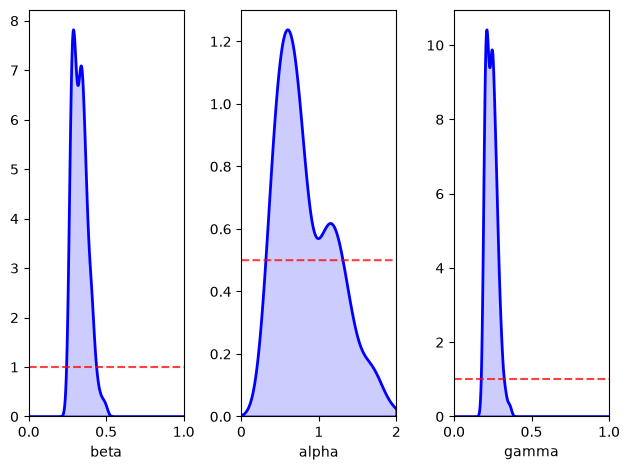

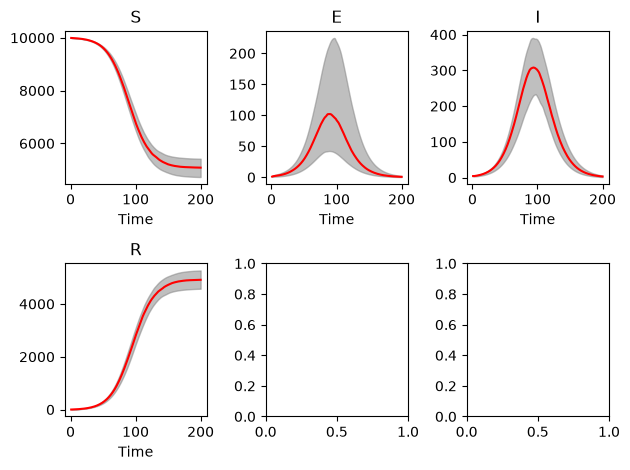

In [8]:
abcSEIR.plot_posterior_histograms();
abcSEIR.plot_pointwise_predictions();

The posterior draws are contained within `abcSIR.res`.
This can be useful if output needs to be saved, or for calculation credible intervals.
We see here that the 95% credible intervals are consistent with the true parameter values.

In [9]:
vars = ['beta', 'alpha', 'gamma']

for i, var in enumerate(vars):
    x = abcSEIR.res[:, i]
    q025, q975 = np.quantile(x, [0.025, 0.975])
    print(f'{var:<6}: {np.median(x):.3f} ({q025:.3f} to {q975:.3f})')

beta  : 0.328 (0.266 to 0.438)
alpha : 0.732 (0.340 to 1.701)
gamma : 0.238 (0.191 to 0.320)


## Fitting an SEIR model (with only Infected known)

We now fit the same model, but assume we only have access to data concerning the infected component.
All that changes code-wise is that we omit the recovered time series when inputting the data and specify that we only have information for the infected population in the last argument of `create_loss`.
We do this and run the ABC algorithm for 5 generations.

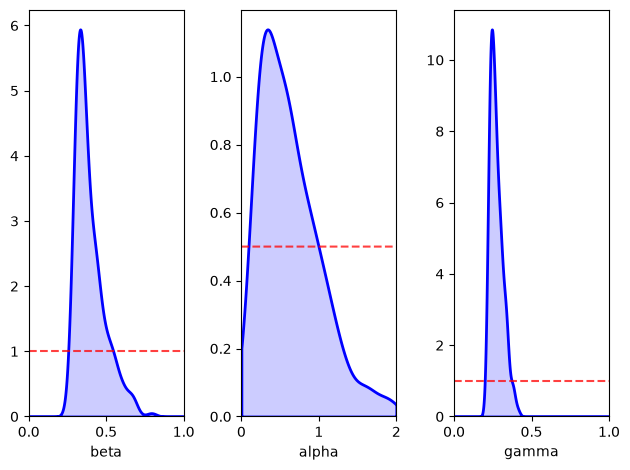

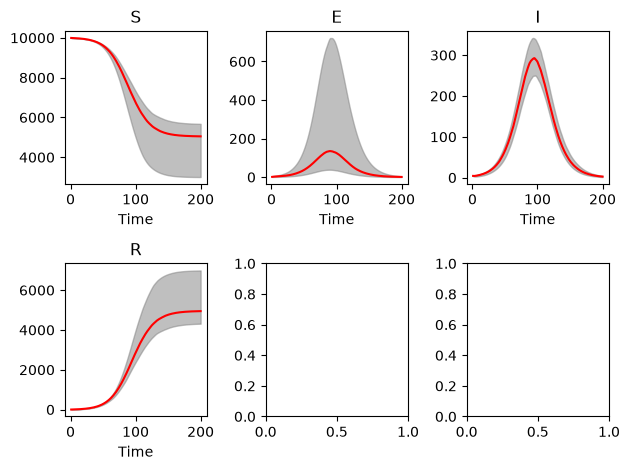

In [10]:
objSEIR2 = abc.create_loss(
    "PoissonLoss",
    parameters,
    ode_SEIR,
    x0, t[0],
    t[1:], sol_i_r[1:,0],  # now we only pass one column of epi data
    ['I']                  # now we only have information regarding the infected compartment
)

abcSEIR2 = abc.ABC(objSEIR2, parameters)

abcSEIR2.get_posterior_sample(N=250, tol=np.inf, G=6, q=0.25, progress=True)
abcSEIR2.plot_posterior_histograms();
abcSEIR2.plot_pointwise_predictions();

In [11]:
vars = ['beta', 'alpha', 'gamma']

for i, var in enumerate(vars):
    x = abcSEIR2.res[:, i]
    q025, q975 = np.quantile(x, [0.025, 0.975])
    print(f'{var:<6}: {np.median(x):.3f} ({q025:.3f} to {q975:.3f})')

beta  : 0.361 (0.289 to 0.640)
alpha : 0.543 (0.160 to 1.598)
gamma : 0.263 (0.218 to 0.375)


We still see estimates in agreement with the true parameter values, even though we have reduced the amount of data made available to the ABC algorithm.

## Fitting an SIR model (with only Infected known)

Of course, we may not know the underlying mechanisms and might instead attempt to fit an SIR model to the infected data.
We follow similar steps as before, but now specifying an SIR model:

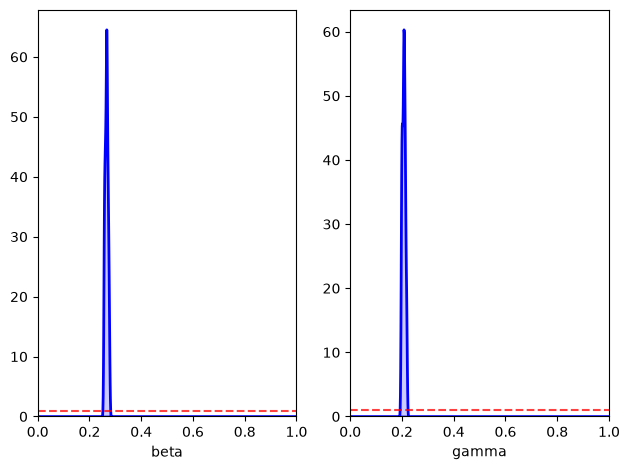

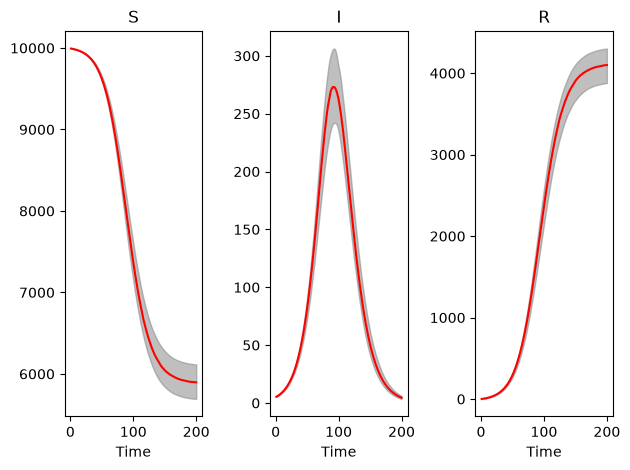

In [12]:
parameters = [
    abc.Parameter('beta', 'unif', 0, 1, logscale=False),
    abc.Parameter('gamma', 'unif', 0, 1, logscale=False)
]

# Params
paramEval=[('beta', 0), ('gamma', 0), ('N', n_pop)]

# Initial conditions now doen't require E0
x0=[n_pop-i0, i0, 0]

# Set up pygom object
ode_SIR = common_models.SIR(param=paramEval)

objSIR = abc.create_loss(
    "PoissonLoss",
    parameters,
    ode_SIR,
    x0, t[0],
    t[1:], sol_i_r[1:,0],
    ['I']
)
abcSIR = abc.ABC(objSIR, parameters)

abcSIR.get_posterior_sample(N=250, tol=np.inf, G=6, q=0.25, progress=True)

abcSIR.plot_posterior_histograms();
abcSIR.plot_pointwise_predictions();

Although we see smaller credible intervals, this actually reflects the restriction in model fitting, rather than increased precision.
We see that our inappropriate model choice here results in poorer parameter estimates:

In [13]:
vars = ['beta', 'gamma']

for i, var in enumerate(vars):
    x = abcSEIR.res[:, i]
    q025, q975 = np.quantile(x, [0.025, 0.975])
    print(f'{var:<6}: {np.median(x):.3f} ({q025:.3f} to {q975:.3f})')

beta  : 0.328 (0.266 to 0.438)
gamma : 0.732 (0.340 to 1.701)


## Initial conditions

In addition to inferring model parameters, the ABC methods can be used to estimate initial conditions, after all, it is unlikely that $I(t=0)$ is known with certainty.
To do this, the state that we wish to estimate the initial condition for should be included in the `parameters`:

In [14]:
parameters = [
    abc.Parameter('beta', 'unif', 0, 1, logscale=False),
    abc.Parameter('alpha', 'unif', 0, 2, logscale=False),
    abc.Parameter('gamma', 'unif', 0, 1, logscale=False),
    abc.Parameter('I', 'unif', 0, 20, logscale=False)
]

The remaining code is the same as before.
Again, we still need to pass variables even if they are unknown - in this case the initial number of infected individuals.

In [15]:
i0=5
x0=[n_pop-i0, 0, i0, 0]

objSEIR3 = abc.create_loss(
    "PoissonLoss",
    parameters,
    ode_SEIR,
    x0, t[0],
    t[1:], sol_i_r[1:, 0],   # now we only pass one column of epi data
    ['I']                   # now we only have information regarding the infected compartment
)

abcSEIR3 = abc.ABC(objSEIR3, parameters)

We run the algorithm for 5 generations:

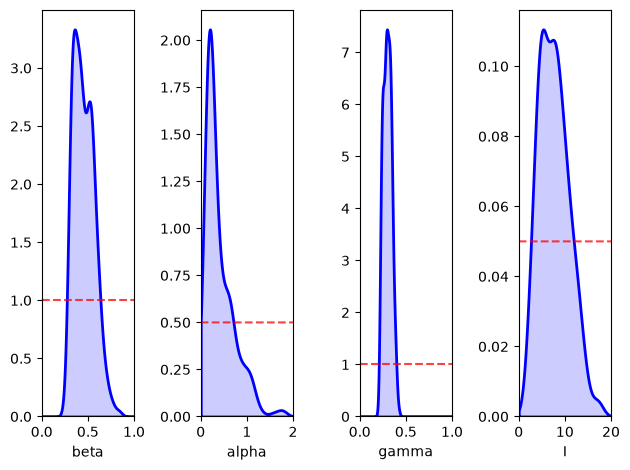

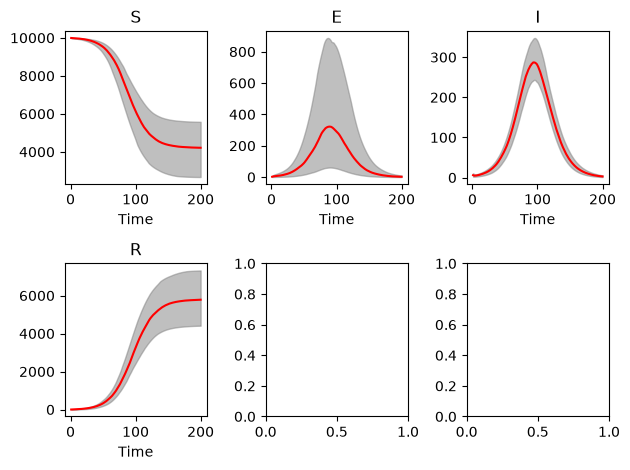

In [17]:
abcSEIR3.get_posterior_sample(N=250, tol=np.inf, G=6, q=0.25, progress=True)

abcSEIR3.plot_posterior_histograms();
abcSEIR3.plot_pointwise_predictions();

In [18]:
vars = ['beta', 'alpha', 'gamma', 'I0']

for i, var in enumerate(vars):
    x = abcSEIR3.res[:, i]
    q025, q975 = np.quantile(x, [0.025, 0.975])
    print(f'{var:<6}: {np.median(x):.3f} ({q025:.3f} to {q975:.3f})')

beta  : 0.440 (0.307 to 0.689)
alpha : 0.266 (0.119 to 1.130)
gamma : 0.295 (0.227 to 0.384)
I0    : 7.406 (2.517 to 14.091)


Whilst credible intervals are consistent with our parameters, they are wider than before.
This is because with increased numbers of parameters there are more ways for our model to fit the data.